# **Introduction**

# Import Libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict, cross_validate
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [2]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Load Data

In [3]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
print('train data:', train.shape)
print('test data:', test.shape)

train data: (891, 12)
test data: (418, 11)


In [4]:
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# EDA

In [5]:
# ========================
# General Info
# ========================

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# =============================
# Unique Data
# =============================

train.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

- A lot unique data like: `PassengerId`, `Name`, `Ticket`, `Cabin` so, I guessing if we can do without them.

## Missing Values

In [7]:
# =============================
# Duplicate data?
# =============================

train.duplicated().sum()

np.int64(0)

In [8]:
# =============================
# Null Data
# =============================

train.isnull().sum().sort_values(ascending = False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

- Cabin has 687 null values so, we can do without it.  
- Age has 177 null values, but we can impute some data, we will see that later.

In [9]:
# =====================================
# taking a look at numerical variables
# =====================================

col_numerical = train.select_dtypes(include=[np.number])
col_numerical.head(5)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [10]:
col_numerical.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
def describe_v2(df_numerical):
    for i in df_numerical:
        print(f"Column: {df_numerical[i].name}")
        print(f"Mode: {df_numerical[i].mode()[0]}")
        # print(f"Sum: {round(df_numerical[i].sum(),2)}")
        print(f"Range: {round(df_numerical[i].max() - df_numerical[i].min())}")
        print(f"Interquartile Range: {round(df_numerical[i].quantile(0.75) - df_numerical[i].quantile(0.25),2)}")
        # print(f"Average: {round(df_numerical[i].mean(),2)}")
        # print(f"Std: {round(df_numerical[i].std(),2)}")
        print(f"Variance: {round(df_numerical[i].var(),2)}")
        # Spacer
        print("="*25)
        
describe_v2(col_numerical.iloc[:, 2:])

Column: Pclass
Mode: 3
Range: 2
Interquartile Range: 1.0
Variance: 0.7
Column: Age
Mode: 24.0
Range: 80
Interquartile Range: 17.88
Variance: 211.02
Column: SibSp
Mode: 0
Range: 8
Interquartile Range: 1.0
Variance: 1.22
Column: Parch
Mode: 0
Range: 6
Interquartile Range: 0.0
Variance: 0.65
Column: Fare
Mode: 8.05
Range: 512
Interquartile Range: 23.09
Variance: 2469.44


- We have a hint to impute the nan values of `Age`

In [12]:
def print_nunique_var(columns):
    for col in columns:
        if train[col].nunique()<= 10:
            print(col, ':', train[col].unique())

print_nunique_var(col_numerical)

Survived : [0 1]
Pclass : [3 1 2]
SibSp : [1 0 3 4 2 5 8]
Parch : [0 1 2 5 3 4 6]


- Survived -> Categorical: 0 = No, 1 = yes | target
- Pclass -> Categorical: 1 = 1st (Upper), 2 = 2nd (Middle), 3 = 3rd (lower)
- SibSp -> Num of siblings / spouses aboard the Titanic
- Parch	-> Num of parents / children aboard the Titanic	

In [13]:
# ======================================
# taking a look at categorical variables
# ======================================
col_categorical = train.select_dtypes(exclude=[np.number])
col_categorical.head(5)

,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S


In [14]:
print_nunique_var(col_categorical)

Sex : ['male' 'female']
Embarked : ['S' 'C' 'Q' nan]


- Sex -> Categorical
- Embarked -> Categorical: C = Cherbourg, Q = Queenstown, S = Southampton

In [15]:
print(f"Embarked mode: {col_categorical['Embarked'].mode()[0]}")

Embarked mode: S


- We have a hint to impute the nan values of `Embarked`

## Target Distribution

In [16]:
counts = train['Survived'].value_counts()
percentage = ((train['Survived'].value_counts()/len(train)) * 100)

dist_survived = pd.DataFrame({
    'Passangers' : counts,
    'Porcentaje' : percentage,
}) 

dist_survived

,Passangers,Porcentaje
Survived,,
0,549,61.616162
1,342,38.383838


<Axes: xlabel='Survived', ylabel='count'>

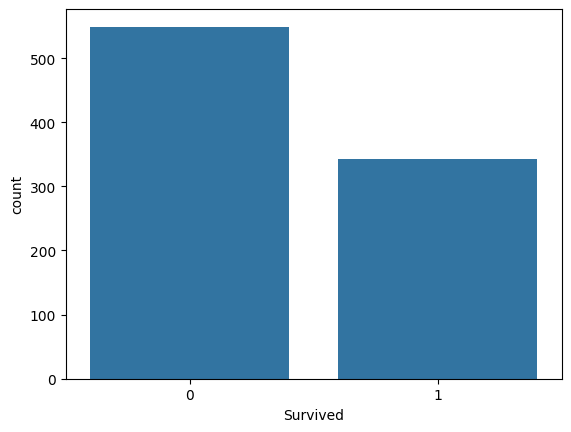

In [17]:
sns.countplot(x ='Survived', data = train)

- 549 passengers survived, on the other hand 342 passengers did not survive

## Variables Distribution

<Figure size 1200x800 with 0 Axes>

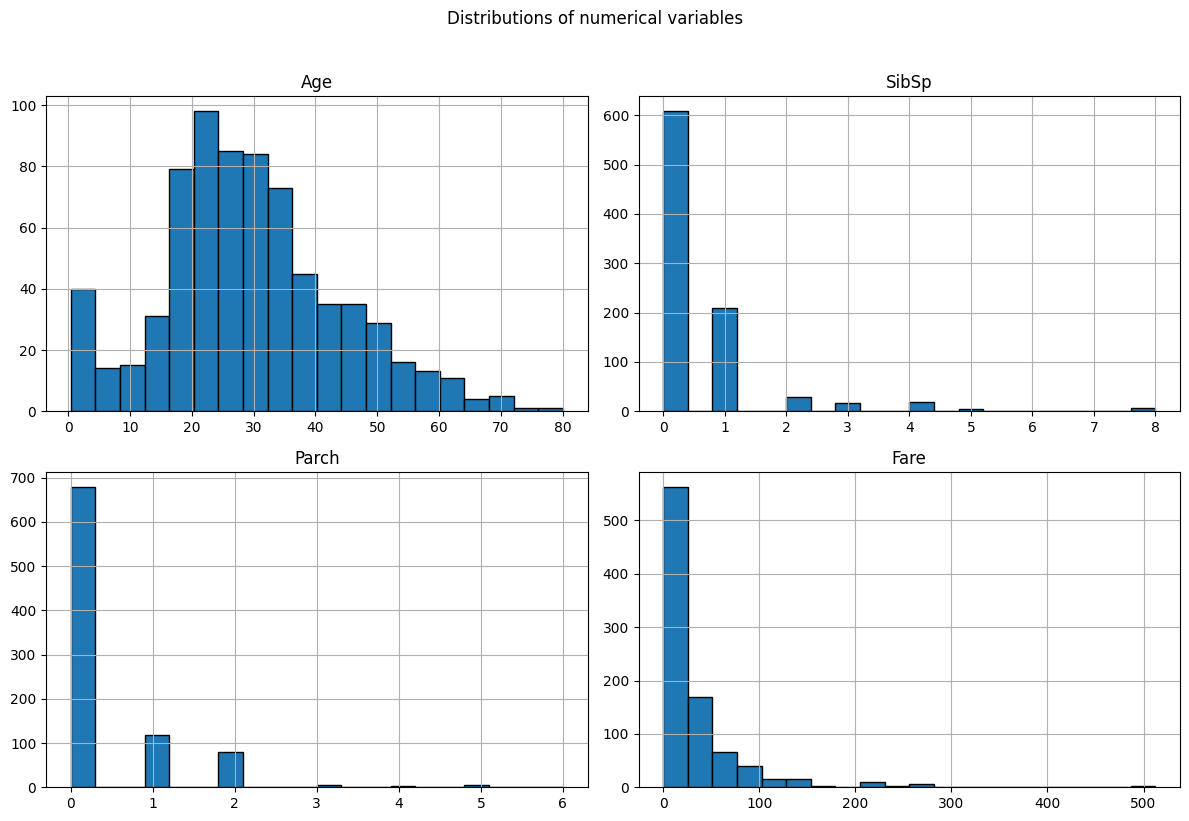

In [18]:
# =====================================
# Distributions of numerical variables
# =====================================
plt.figure(figsize=(12, 8))
col_numerical.iloc[:, 3:].hist(figsize=(12, 8), bins=20, edgecolor="black")
plt.suptitle("Distributions of numerical variables", y=1.02)
plt.tight_layout()
plt.show()

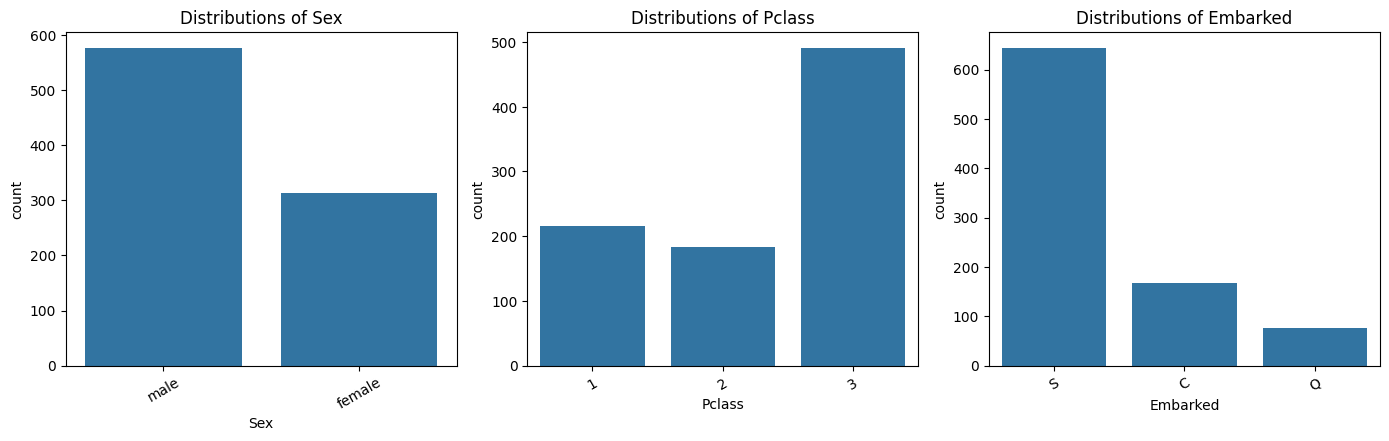

In [19]:
# =====================================
# Distributions of categrical variables
# =====================================
plt.figure(figsize=(14, 8))
plot_cols = plot_cols = ["Sex", "Pclass", "Embarked"]
for i, col in enumerate(plot_cols, 1):
    if col in train.columns:
        plt.subplot(2, 3, i)
        sns.countplot(x=col, data=train)
        plt.title(f"Distributions of {col}")
        plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

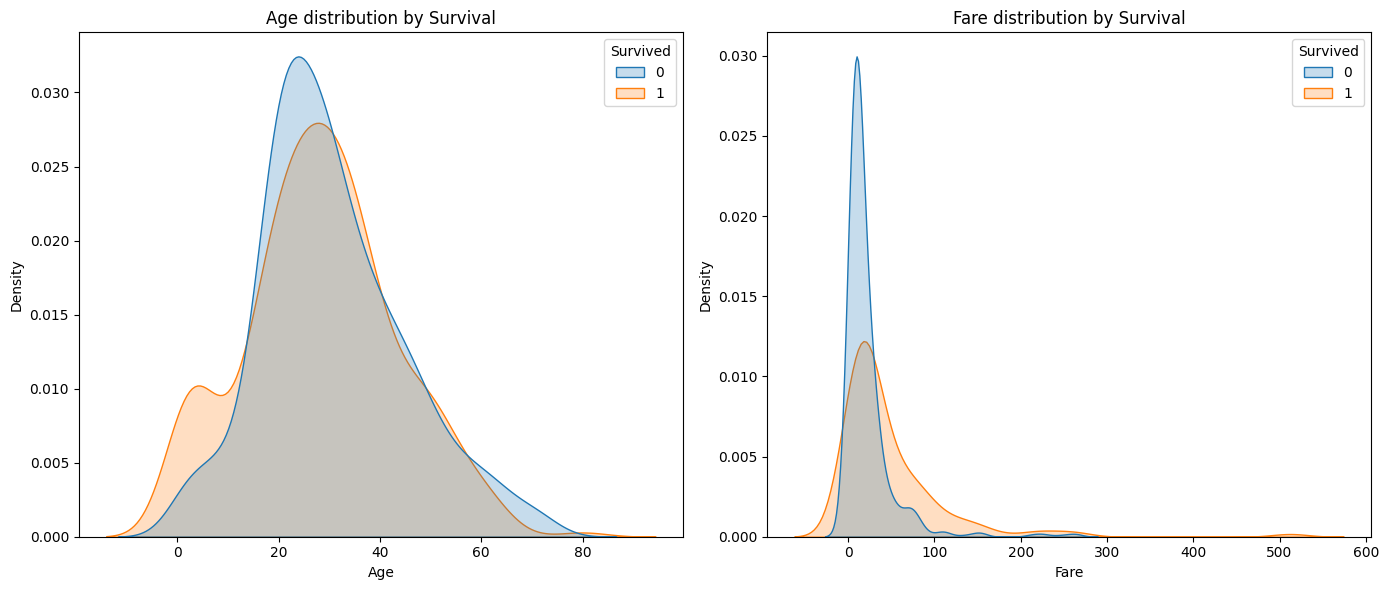

In [20]:
# =====================================
# Survival by Age y Fare
# =====================================

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(data=train, x="Age", hue="Survived", common_norm=False, fill=True)
plt.title("Age distribution by Survival")

plt.subplot(1, 2, 2)
sns.kdeplot(data=train, x="Fare", hue="Survived", common_norm=False, fill=True)
plt.title("Fare distribution by Survival")

plt.tight_layout()
plt.show()

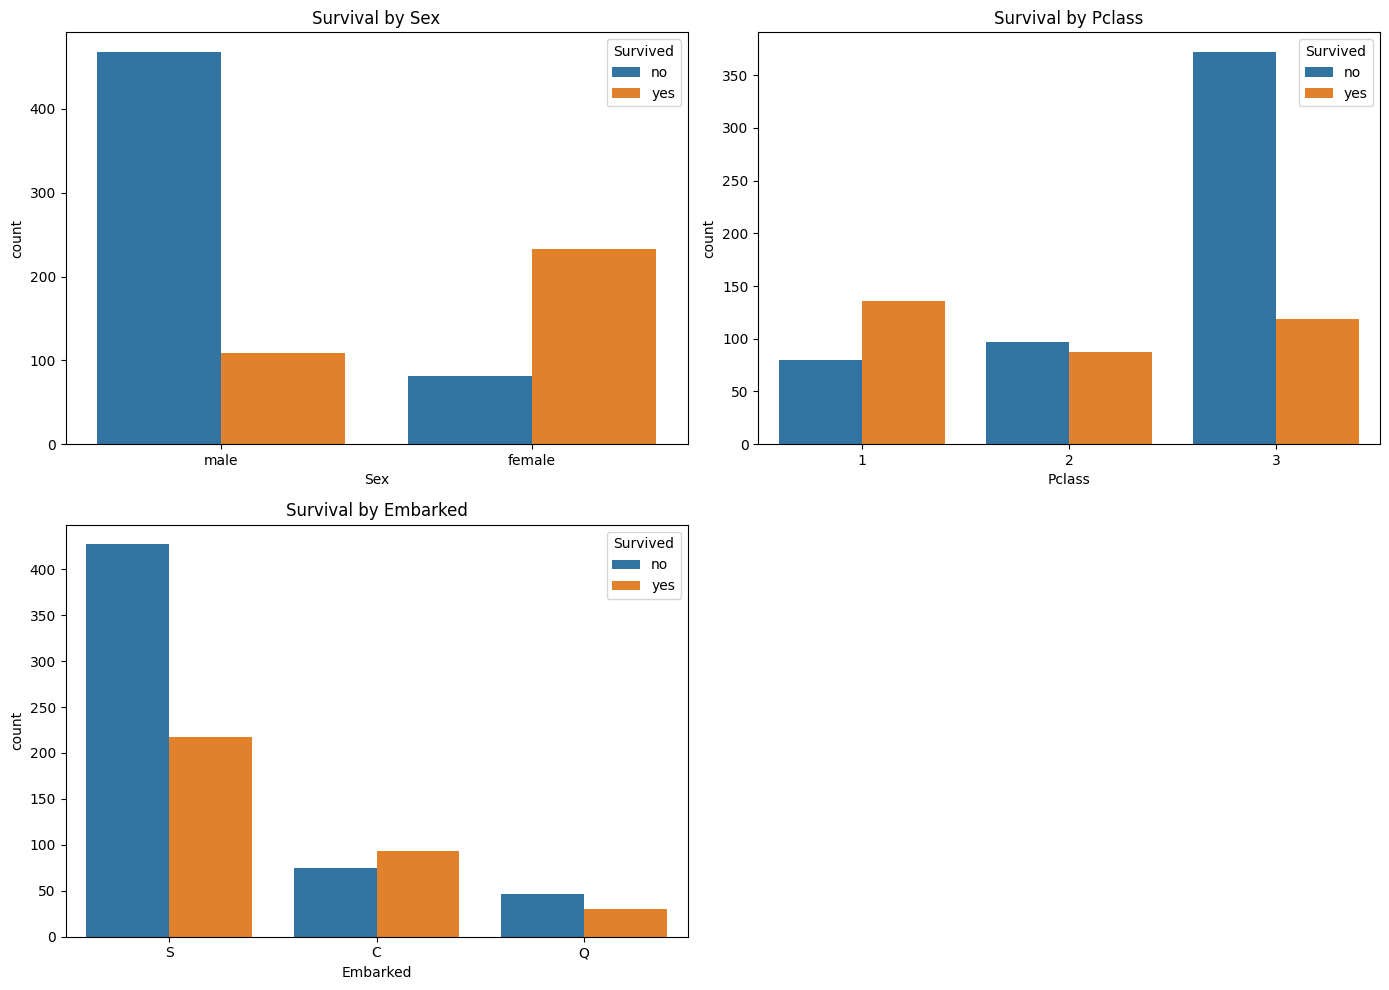

In [21]:
# =====================================
# Survival by Sex, Pclass y Embarked
# =====================================
def plot_survival_by_categories(df, columns, labels=["no", "yes"]):
    n = len(columns)
    rows = math.ceil(n / 2)

    plt.figure(figsize=(14, 5 * rows))

    for i, col in enumerate(columns, 1):
        plt.subplot(rows, 2, i)
        sns.countplot(x=col, hue="Survived", data=df)
        plt.title(f"Survival by {col}")
        plt.legend(title="Survived", labels=labels)

    plt.tight_layout()
    plt.show()
    
plot_survival_by_categories(train, columns=["Sex", "Pclass", "Embarked"])

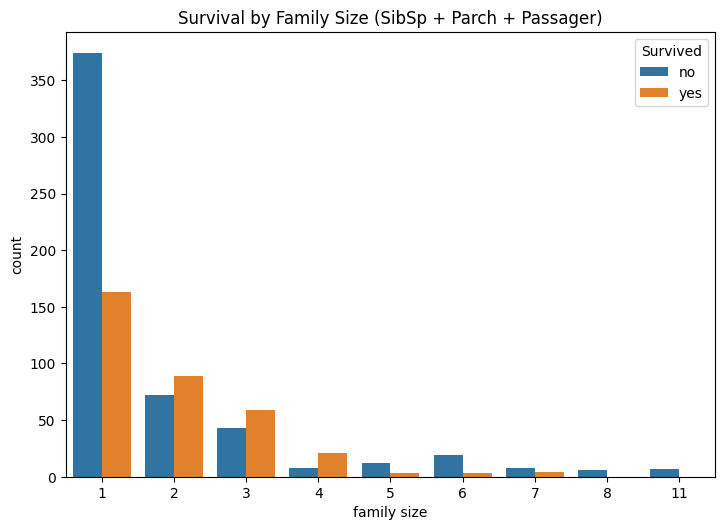

In [22]:
# ==========================================
# Survival by family siza(SibSp + Parch +1)
# ==========================================
labels=["no", "yes"]
plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 4)

# family size = siblings/spouses + parents/children + passenger
family_size = train["SibSp"] + train["Parch"] + 1
sns.countplot(x=family_size, hue=train["Survived"])
plt.title("Survival by Family Size (SibSp + Parch + Passager)")
plt.xlabel("family size")
plt.legend(title="Survived", labels=labels)

plt.tight_layout()
plt.show()

Thinking about the family size, the family group is represented by the sib/sp + parch + 1, because we are adding my family and me;  
e.g.: if someone travels with 1 husband (SibSp=1) and 2 children (Patch=2), the size of their family will be (1 + 2 + 1 = 4) group of people.

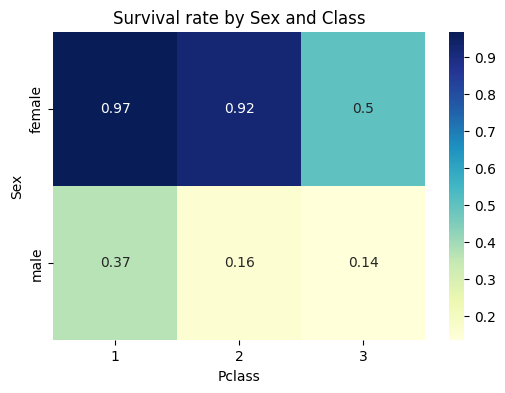

In [23]:
# =====================================
# Survival rate by sex and class
# =====================================

rate_sex_pclass = (
    train
    .groupby(["Sex", "Pclass"]) ["Survived"]
    .mean()
    .unstack()
)

plt.figure(figsize=(6, 4))
sns.heatmap(rate_sex_pclass, annot=True, cmap="YlGnBu") #fmt=".2f")
plt.title("Survival rate by Sex and Class")
plt.ylabel("Sex")
plt.xlabel("Pclass")
plt.show()

## Correlation

In [24]:
train_encoded = train.copy()
train_encoded = train_encoded.drop(columns=['Ticket','Cabin', 'Name', 'PassengerId'])
train_encoded.sample(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
635,1,2,female,28.0,0,0,13.0000,S
6,0,1,male,54.0,0,0,51.8625,S
543,1,2,male,32.0,1,0,26.0000,S


In [25]:
train_encoded = pd.get_dummies(train_encoded, columns=['Sex', 'Embarked'], dtype=int) #, drop_first=True)
train_encoded.sample(3)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
333,0,3,16.0,2,0,18.00,0,1,0,0,1
406,0,3,51.0,0,0,7.75,0,1,0,0,1
782,0,1,29.0,0,0,30.00,0,1,0,0,1


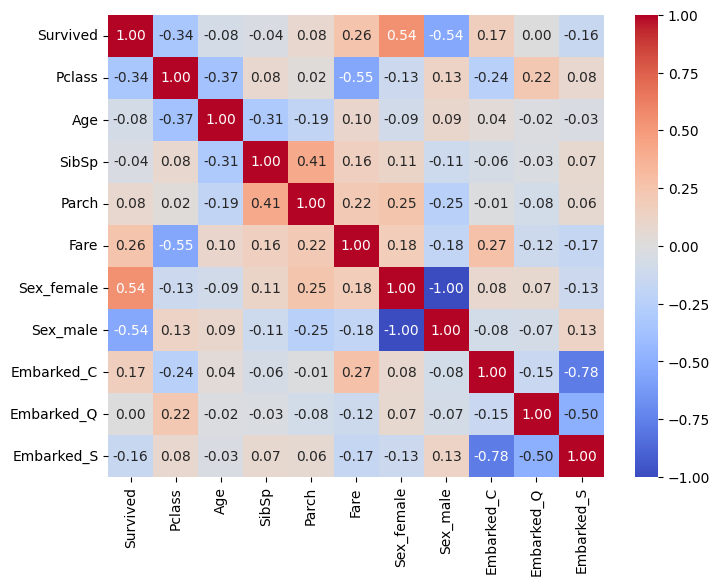

In [26]:
plt.figure(figsize=(8, 6))
corr = train_encoded.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

In [27]:
# =====================================
# Correlation with the Survived
# =====================================
def predictive_power(df):
    df_corr = df.copy()
    correlation_matrix = df_corr.corr()
    
    correlation_with_target = (
        correlation_matrix["Survived"]
        .drop("Survived")
        .abs()
        .sort_values(ascending=False)
    )
    
    # Rule w filter variables with significant correlation
    significant_predictors = correlation_with_target[correlation_with_target > 0.1]
    return significant_predictors
    
print("Variables with greater predictive power compared to 'Survived':")
print(predictive_power(train_encoded))

Variables with greater predictive power compared to 'Survived':
Sex_male      0.543351
Sex_female    0.543351
Pclass        0.338481
Fare          0.257307
Embarked_C    0.168240
Embarked_S    0.155660
Name: Survived, dtype: float64


# Data Cleaning

In [28]:
titanic = train.copy()
titanic.sample(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
44,45,1,3,"Devaney, Miss. Margaret Delia",female,19.0,0,0,330958,7.8792,NaN,Q
53,54,1,2,"Faunthorpe, Mrs. Lizzie (Elizabeth Anne Wilkin...",female,29.0,1,0,2926,26.0000,NaN,S
383,384,1,1,"Holverson, Mrs. Alexander Oskar (Mary Aline To...",female,35.0,1,0,113789,52.0000,NaN,S
467,468,0,1,"Smart, Mr. John Montgomery",male,56.0,0,0,113792,26.5500,NaN,S


In [29]:
# ==========================================
# Cabin == NaN to 'Unknown' -> imputation
# ==========================================
# titanic['Cabin'] = titanic['Cabin'].fillna('Unknown')
# titanic.head(3)

In [30]:
# ==============================================
# Embarked == NaN to Embarked.mode -> imputation
# ==============================================
def embarked_imputation(df):
    mode_embarked = df['Embarked'].mode()[0]
    df['Embarked'] = df['Embarked'].fillna(mode_embarked)
    return df

titanic = embarked_imputation(titanic)
titanic.sample(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.00,1,5,347082,31.2750,NaN,S
610,611,0,3,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",female,39.00,1,5,347082,31.2750,NaN,S
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
217,218,0,2,"Jacobsohn, Mr. Sidney Samuel",male,42.00,1,0,243847,27.0000,NaN,S


In [31]:
# ==========================================
# Age == NaN to Age.median -> imputation
# ==========================================
def age_imputation(df):
    age_median_by_group = df.groupby(["Sex", "Pclass"])["Age"].transform("median")
    df["Age"] = df["Age"].fillna(age_median_by_group)
    return df

titanic = age_imputation(titanic)
titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


# Feature engineering

In [32]:
# ==========================================
# Survival by family size (SibSp + Parch +1)
# ==========================================
def featureEngineer_df(df):
    df['familySize'] = df['SibSp'] + df['Parch'] + 1
    return df

titanic = featureEngineer_df(titanic)
titanic.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,familySize
648,649,0,3,"Willey, Mr. Edward",male,25.0,0,0,S.O./P.P. 751,7.5500,NaN,S,1
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,1
148,149,0,2,"Navratil, Mr. Michel (""Louis M Hoffman"")",male,36.5,0,2,230080,26.0000,F2,S,3


# Preprocesing Data

In [33]:
# =========================================================
# Droping PassengerId, Name, Ticket, SibSp, Parch and Cabin
# =========================================================
def droping_features(df):
    df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'])
    df.sample(3)
    return df

titanic = droping_features(titanic)

In [34]:
titanic.sample(4)

,Survived,Pclass,Sex,Age,Fare,Embarked,familySize
399,1,2,female,28.0,12.6500,S,1
576,1,2,female,34.0,13.0000,S,1
514,0,3,male,24.0,7.4958,S,1
523,1,1,female,44.0,57.9792,C,2


In [35]:
# ========================================
# Variables: Sex and Embarked to Category
# ========================================

def asCategory(list, df):
    for l in list:
        df[l] = df[l].astype('category')
    return df

catList = ['Sex','Embarked']
asCategory(catList, titanic)
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    int64   
 2   Sex         891 non-null    category
 3   Age         891 non-null    float64 
 4   Fare        891 non-null    float64 
 5   Embarked    891 non-null    category
 6   familySize  891 non-null    int64   
dtypes: category(2), float64(2), int64(3)
memory usage: 36.9 KB


## Train Validation Split

In [36]:
X = titanic.drop(columns=['Survived'])
y = titanic['Survived'] #.to_numpy()

In [37]:
print(X.head(3))
print(X.shape)

   Pclass     Sex   Age     Fare Embarked  familySize
0       3    male  22.0   7.2500        S           2
1       1  female  38.0  71.2833        C           2
2       3  female  26.0   7.9250        S           1
(891, 6)


## Preporcessor

In [38]:
# ========================================
# OHE and Scaler the data
# ========================================
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(sparse_output = False), catList),
        ('num', StandardScaler(),['Pclass', 'Age', 'Fare', 'familySize'])
        
    ]
)

# Hyperparameter Tuning

In [39]:
def evaluate_models(pipelines, X, y, n_splits=10):
    """
    Evaluate multiple models with stratified cross-validation.
    
    parameters:
        pipelines : dict  → {'name': model_or_pipeline}
        X         : df    → features
        y         : array → target
        n_splits  : int   → # of folds (default 10)
    """
    y_vec  = np.asarray(y).ravel()
    kfold  = StratifiedKFold(n_splits=n_splits, shuffle=True)

    def error_rate(y_true, y_pred):
        return 1 - accuracy_score(y_true, y_pred)

    metricas = {
        'accuracy'  : 'accuracy',
        'f1_macro'  : 'f1_macro',
        'error_rate': make_scorer(error_rate)
    }

    last_pipelines = {}
    for name, estimator in pipelines.items():
        if isinstance(estimator, Pipeline):
            last_pipelines[name] = estimator
        else:
            last_pipelines[name] = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('classifier',   estimator)
            ])

    # ========================================
    # Evaluation
    # ========================================
    resultados = {}
    for name, pipeline in last_pipelines.items():
        resultados[name] = cross_validate(
            estimator=pipeline,
            X=X,
            y=y_vec,
            cv=kfold,
            scoring=metricas,
            return_train_score=False
        )

    # ========================================
    # Report
    # ========================================
    for name, res in resultados.items():
        print(f"Model: {name}")
        print(f"  Accuracy  : {res['test_accuracy'].mean():.4f} ± {res['test_accuracy'].std():.4f}")
        print(f"  F1 macro  : {res['test_f1_macro'].mean():.4f} ± {res['test_f1_macro'].std():.4f}")
        print(f"  Error     : {res['test_error_rate'].mean():.4f} ± {res['test_error_rate'].std():.4f}")
        print()

    return last_pipelines

In [40]:
print(X.head(3))
print(X.shape)

   Pclass     Sex   Age     Fare Embarked  familySize
0       3    male  22.0   7.2500        S           2
1       1  female  38.0  71.2833        C           2
2       3  female  26.0   7.9250        S           1
(891, 6)


## SVC

In [61]:
pipelines = {
    'sigmoid': SVC(kernel='sigmoid', gamma='scale'),
    'rbf': SVC(kernel='rbf', gamma='scale'),
    'poly': SVC(kernel='poly', gamma='scale'),
}

results = evaluate_models(pipelines, X, y)

Model: sigmoid
  Accuracy  : 0.6869 ± 0.0339
  F1 macro  : 0.6680 ± 0.0364
  Error     : 0.3131 ± 0.0339

Model: rbf
  Accuracy  : 0.8238 ± 0.0348
  F1 macro  : 0.8067 ± 0.0372
  Error     : 0.1762 ± 0.0348

Model: poly
  Accuracy  : 0.8160 ± 0.0324
  F1 macro  : 0.7972 ± 0.0363
  Error     : 0.1840 ± 0.0324



This means that the model SVC with `rbf` achieved an average accuracy of 82.60%, but the result varied approximately ±5.22 percentage points between folds.

In [62]:
m_svc = pipelines['rbf']

## KNN

In [63]:
pipelines = {
    'ball_tree': KNeighborsClassifier(n_neighbors=10, algorithm='ball_tree'),
    'kd_tree'  : KNeighborsClassifier(n_neighbors=10, algorithm='kd_tree'),
    'brute'    : KNeighborsClassifier(n_neighbors=10, algorithm='brute'),
}

results = evaluate_models(pipelines, X, y)

Model: ball_tree
  Accuracy  : 0.8092 ± 0.0234
  F1 macro  : 0.7874 ± 0.0262
  Error     : 0.1908 ± 0.0234

Model: kd_tree
  Accuracy  : 0.8092 ± 0.0251
  F1 macro  : 0.7875 ± 0.0283
  Error     : 0.1908 ± 0.0251

Model: brute
  Accuracy  : 0.8193 ± 0.0337
  F1 macro  : 0.7983 ± 0.0422
  Error     : 0.1807 ± 0.0337



In [64]:
m_knn = pipelines['brute']

## DecisionTreeClassifier

In [65]:
pipelines = {
    'gini' : DecisionTreeClassifier(criterion='gini', max_depth=4, min_samples_split=2, min_samples_leaf=2),
    'entropy' : DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_split=2, min_samples_leaf=2),
    'log_loss' : DecisionTreeClassifier(criterion='log_loss', max_depth=4, min_samples_split=2, min_samples_leaf=2),
}

results = evaluate_models(pipelines, X, y)

Model: gini
  Accuracy  : 0.8070 ± 0.0258
  F1 macro  : 0.7878 ± 0.0289
  Error     : 0.1930 ± 0.0258

Model: entropy
  Accuracy  : 0.8193 ± 0.0192
  F1 macro  : 0.8036 ± 0.0170
  Error     : 0.1807 ± 0.0192

Model: log_loss
  Accuracy  : 0.8205 ± 0.0380
  F1 macro  : 0.8036 ± 0.0398
  Error     : 0.1795 ± 0.0380



In [66]:
m_tree = pipelines['log_loss']

## AdaBoostClassifier

In [47]:
pipelines = {
    'md_1' : AdaBoostClassifier(n_estimators=21, learning_rate = 0.1, estimator = DecisionTreeClassifier(max_depth=1)),
    'md_2' : AdaBoostClassifier(n_estimators=21, learning_rate = 0.1, estimator = DecisionTreeClassifier(max_depth=2)),
    'md_3' : AdaBoostClassifier(n_estimators=21, learning_rate = 0.1, estimator = DecisionTreeClassifier(max_depth=3)),
}

results = evaluate_models(pipelines, X, y)

Model: md_1
  Accuracy  : 0.7868 ± 0.0333
  F1 macro  : 0.7704 ± 0.0370
  Error     : 0.2132 ± 0.0333

Model: md_2
  Accuracy  : 0.7857 ± 0.0336
  F1 macro  : 0.7533 ± 0.0432
  Error     : 0.2143 ± 0.0336

Model: md_3
  Accuracy  : 0.8249 ± 0.0369
  F1 macro  : 0.8084 ± 0.0406
  Error     : 0.1751 ± 0.0369



In [48]:
m_ada = pipelines['md_3']

## RandomForestClassifier

In [49]:
pipelines = {
    'gini' : RandomForestClassifier(n_estimators=40, criterion='gini'),
    'entropy' : RandomForestClassifier(n_estimators=40, criterion='entropy'),
    'log_loss' : RandomForestClassifier(n_estimators=40, criterion='log_loss'),
}

results = evaluate_models(pipelines, X, y)

Model: gini
  Accuracy  : 0.8069 ± 0.0256
  F1 macro  : 0.7935 ± 0.0280
  Error     : 0.1931 ± 0.0256

Model: entropy
  Accuracy  : 0.8114 ± 0.0293
  F1 macro  : 0.7964 ± 0.0338
  Error     : 0.1886 ± 0.0293

Model: log_loss
  Accuracy  : 0.8171 ± 0.0395
  F1 macro  : 0.8044 ± 0.0414
  Error     : 0.1829 ± 0.0395



In [50]:
m_forest = pipelines['gini']

## GradientBoostingClassifier

In [51]:
pipelines = {
    'lr_005': GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8),
    'lr_01':  GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,  max_depth=3, subsample=0.8),
    'lr_02':  GradientBoostingClassifier(n_estimators=100, learning_rate=0.2,  max_depth=3, subsample=0.8),
}

results = evaluate_models(pipelines, X, y)

Model: lr_005
  Accuracy  : 0.8272 ± 0.0334
  F1 macro  : 0.8116 ± 0.0351
  Error     : 0.1728 ± 0.0334

Model: lr_01
  Accuracy  : 0.8226 ± 0.0272
  F1 macro  : 0.8080 ± 0.0310
  Error     : 0.1774 ± 0.0272

Model: lr_02
  Accuracy  : 0.8350 ± 0.0434
  F1 macro  : 0.8228 ± 0.0453
  Error     : 0.1650 ± 0.0434



In [52]:
m_gradient = pipelines['lr_02']

## LinearDiscriminantAnalysis

In [53]:
pipelines = {
    'svd' : LinearDiscriminantAnalysis(solver = 'svd', shrinkage = None),
    'lsqr' : LinearDiscriminantAnalysis(solver = 'lsqr', shrinkage = 'auto'),
    'eigen' : LinearDiscriminantAnalysis(solver = 'eigen', shrinkage = 'auto'),
}

results = evaluate_models(pipelines, X, y)

Model: svd
  Accuracy  : 0.8013 ± 0.0364
  F1 macro  : 0.7858 ± 0.0407
  Error     : 0.1987 ± 0.0364

Model: lsqr
  Accuracy  : 0.8002 ± 0.0483
  F1 macro  : 0.7852 ± 0.0487
  Error     : 0.1998 ± 0.0483

Model: eigen
  Accuracy  : 0.7957 ± 0.0590
  F1 macro  : 0.7799 ± 0.0625
  Error     : 0.2043 ± 0.0590



In [54]:
m_lda = pipelines['eigen']

## QuadraticDiscriminantAnalysis

In [55]:
pipelines = {
    'rp1' : QuadraticDiscriminantAnalysis(reg_param = 0.1),
    'rp3' : QuadraticDiscriminantAnalysis(reg_param = 0.3),
    'rp5' : QuadraticDiscriminantAnalysis(reg_param = 0.5),
}

results = evaluate_models(pipelines, X, y)

Model: rp1
  Accuracy  : 0.8059 ± 0.0367
  F1 macro  : 0.7831 ± 0.0427
  Error     : 0.1941 ± 0.0367

Model: rp3
  Accuracy  : 0.8047 ± 0.0292
  F1 macro  : 0.7783 ± 0.0349
  Error     : 0.1953 ± 0.0292

Model: rp5
  Accuracy  : 0.7755 ± 0.0494
  F1 macro  : 0.7366 ± 0.0594
  Error     : 0.2245 ± 0.0494



In [56]:
m_qda = pipelines['rp1']

## Cross-validation between Models

In [58]:
from sklearn.base import clone

In [67]:
y_vec  = np.asarray(y).ravel()
clases = np.unique(y_vec)
kfold  = StratifiedKFold(n_splits=10, shuffle=True)

def tasa_error(y_true, y_pred):
    return 1 - accuracy_score(y_true, y_pred)

error_scorer = make_scorer(tasa_error)

metricas = {
    'accuracy'  : 'accuracy',
    'f1_macro'  : 'f1_macro',
    'tasa_error': error_scorer
}

pipelines = {
    'svc'       : m_svc,
    'knn'       : m_knn,
    'bayes'     : GaussianNB(),
    'tree'      : m_tree,
    'ada'       : m_ada,
    'forest'    : m_forest,
    'gradient'  : m_gradient,
    'lda'       : m_lda,
    'qda'       : m_qda    
}

pipelines = {
    name: Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),  # copia independiente
        ('classifier',   modelo)
    ])
    for name, modelo in pipelines.items()
}

# pipelines = {
#     name: Pipeline(steps=[
#         ('preprocessor', preprocessor),
#         ('classifier',   modelo)
#     ])
#     for name, modelo in pipelines.items()
# }


results = {}

for name, pipeline in pipelines.items():
    results[name] = cross_validate(
        estimator=pipeline,
        X=X,
        y=y_vec,
        cv=kfold,
        scoring=metricas,
        return_train_score=False
    )


rows = []

for name, result in results.items():
    rows.append({
        'modelo'      : name,
        'acc_mean'    : result['test_accuracy'].mean(),
        'acc_std'     : result['test_accuracy'].std(),
        'f1_mean'     : result['test_f1_macro'].mean(),
        'f1_std'      : result['test_f1_macro'].std(),
        'error_mean'  : result['test_tasa_error'].mean(),
        'error_std'   : result['test_tasa_error'].std(),
    })

df_results = pd.DataFrame(rows).set_index('modelo')
df_results.sort_values('error_mean', ascending = True)

,acc_mean,acc_std,f1_mean,f1_std,error_mean,error_std
modelo,,,,,,
gradient,0.832747,0.042261,0.819100,0.045345,0.167253,0.042261
svc,0.824919,0.039929,0.806867,0.046286,0.175081,0.039929
ada,0.820449,0.029135,0.803292,0.033247,0.179551,0.029135
tree,0.819413,0.041134,0.800663,0.050459,0.180587,0.041134
forest,0.810300,0.023450,0.797713,0.025511,0.189700,0.023450
knn,0.803620,0.025973,0.780019,0.034668,0.196380,0.025973
lda,0.798015,0.033074,0.782328,0.036853,0.201985,0.033074
qda,0.797940,0.042195,0.774232,0.047473,0.202060,0.042195
bayes,0.787865,0.030832,0.775660,0.033041,0.212135,0.030832


# Final Model

In [68]:
model = pipelines['gradient']
noimprimir = model.fit(X, y)

In [69]:
import pickle

with open("gradient_model.pkl", 'wb') as file:
    pickle.dump(model, file)

In [70]:
with open("gradient_model.pkl", 'rb') as file:  
  model = pickle.load(file)

# Preprocess before final pred 

In [71]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [72]:
test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [73]:
def preprocess_test(df, list):
    df = test.copy()
    df = embarked_imputation(df)
    df = age_imputation(df)
    df = featureEngineer_df(df)
    df = droping_features(df)
    mode_fare = df['Fare'].median()    
    df['Fare'] = df['Fare'].fillna(mode_fare)
    df = asCategory(catList, df)
    return df

In [74]:
titanic_test = preprocess_test(test, catList)
titanic_test.sample(3)

,Pclass,Sex,Age,Fare,Embarked,familySize
144,1,male,42.0,26.5500,S,1
113,3,female,18.5,7.2833,Q,1
85,3,male,24.0,14.4542,C,2


In [75]:
titanic_test.isna().sum()

Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
familySize    0
dtype: int64

# Prediction

In [76]:
prediction = model.predict(titanic_test)
prediction

array([0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

# Submission

In [77]:
# ==========================================
# Submission
# ==========================================

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': prediction
})

submission.to_csv('submission.csv', index=False)
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,1
3,895,0
4,896,0
